# The Transformer block

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from mpl_toolkits.mplot3d import Axes3D # for 3D plotting

import torch
import torch.nn as nn
import torch.nn.functional as F

## Demo of linear separation after dimensionality expansion

/var/folders/xb/2p09rqt55sj85gtsqtnpdnvh0000gp/T/ipykernel_32413/2880953350.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


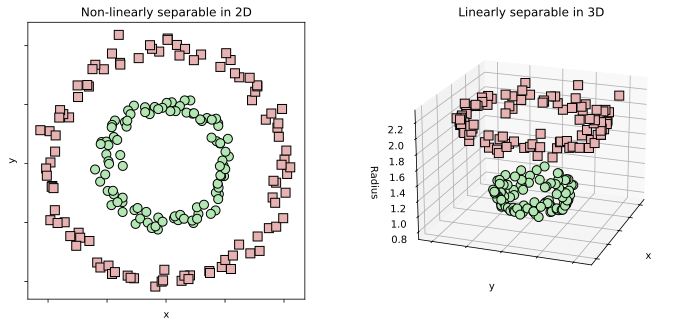

In [3]:
# angles
n = 100
theta = np.linspace(0, 2*np.pi-1/n, n)

# coordinates in 2D
x_inner = 1*np.cos(theta) + np.random.randn(n)/10
y_inner = 1*np.sin(theta) + np.random.randn(n)/10
x_outer = 2*np.cos(theta) + np.random.randn(n)/10
y_outer = 2*np.sin(theta) + np.random.randn(n)/10

# dimensionality-expansion via nonlinear transform
z_inner = np.sqrt(x_inner**2 + y_inner**2)
z_outer = np.sqrt(x_outer**2 + y_outer**2)

### 2D scatter plot
fig = plt.figure(figsize=(12,5))
ax0 = fig.add_subplot(121)

ax0.plot(x_inner, y_inner, 'ko', markerfacecolor=[.7,.9,.7], markersize=9)
ax0.plot(x_outer, y_outer, 'ks', markerfacecolor=[.9,.7,.7], markersize=9)
ax0.axis('square')
ax0.set(title='Non-linearly separable in 2D',
        xlabel='x',
        ylabel='y',
        xticklabels=[],
        yticklabels=[])

### 3D scatter plot
ax1 = fig.add_subplot(122, projection='3d')
ax1.plot(x_inner, y_inner, z_inner, 'ko', markerfacecolor=[.7,.9,.7], markersize=9)
ax1.plot(x_outer, y_outer, z_outer, 'ks', markerfacecolor=[.9,.7,.7], markersize=9)
ax1.set(title='Linearly separable in 3D',
        xlabel='x',
        ylabel='y',
        zlabel='Radius',
        xticklabels=[],
        yticklabels=[])
ax1.view_init(20,20)

plt.tight_layout()
plt.show()